# Deep neural networks with residual connection: Layer-Ricci coefficients

This notebook computes the layer-Ricci coefficients of deep neural networks with residual connections.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
import sys
from tqdm.auto import tqdm

sys.path.append(os.path.abspath('..'))
from neural_networks import DNN
from neural_networks_with_residual_connection import ResNet
from ricci_coefficients import Ricci_Coefficients
from helpers import train_model
from datasets import DatasetFactory

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
num_iterations = 10

# Networks depths we consider
depths = [6,8,10,12,14,16]

Using mps device


# 1. Syn-I Dataset

In [23]:
# Load datasets
X_train_circles, y_train_circles = DatasetFactory.make_circles(noise=0.03)
X_test_circles, y_test_circles = DatasetFactory.make_circles(noise=0.03)

layer_ricci_coefficients_res_net = []
for depth in depths:
    layer_ricci_coefs_depth = []
    for _ in tqdm(range(num_iterations), desc=f"Depth={depth}"):
            # Train model
            model = ResNet(input_dimension=2, hidden_units=25, depth=depth, vision_model=True)
            train_model(
                threshold_accuracy=99,
                model=model,
                X_train=X_train_circles,
                y_train=y_train_circles,
                X_test=X_test_circles,
                y_test=y_test_circles
            )
            # Calculate layer Ricci coefficient
            layer_ricci = Ricci_Coefficients(
                model, X_test_circles, 50
            ).layer_ricci_coefficient(curv='Augmented-Forman-Ricci')
            layer_ricci_coefs_depth.append(layer_ricci)
    # Take means
    stacked = np.stack(layer_ricci_coefs_depth, axis=0)
    averaged_results = stacked.mean(axis=0)
    layer_ricci_coefficients_res_net.append(averaged_results)

Depth=6:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=8:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=10:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=12:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=14:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=16:   0%|          | 0/10 [00:00<?, ?it/s]

Text(0, 0.5, 'Layer-Ricci coef.')

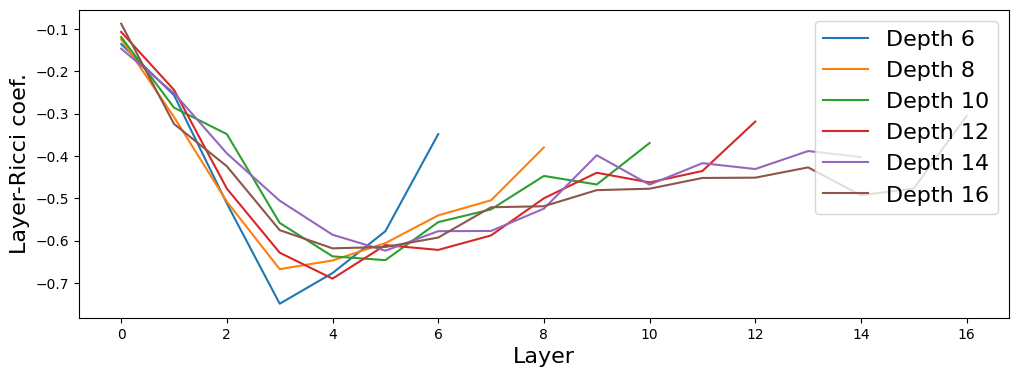

In [ ]:
# Plot results
plt.figure(figsize=(12,4))
for i in range(len(layer_ricci_coefficients_res_net)):
    plt.plot(np.arange(len(layer_ricci_coefficients_res_net[i])-1),layer_ricci_coefficients_res_net[i][:-1], label=f"Depth {6+i*2}")
plt.legend(fontsize=16)
plt.xlabel("Layer", fontsize=16)
plt.ylabel("Layer-Ricci coef.", fontsize=16)

# 2. Syn-II Dataset

In [24]:
# Load datasets
X_train_4circles, y_train_4circles = DatasetFactory.make_4circles()
X_test_4circles, y_test_4circles = DatasetFactory.make_4circles()

layer_ricci_coefficients_res_net = []
for depth in depths:
    layer_ricci_coefs_depth = []
    for _ in tqdm(range(num_iterations), desc=f"Depth={depth}"):
            # Train model
            model = ResNet(input_dimension=2, hidden_units=25, depth=depth, vision_model=False)
            train_model(
                threshold_accuracy=99,
                model=model,
                X_train=X_train_4circles,
                y_train=y_train_4circles,
                X_test=X_test_4circles,
                y_test=y_test_4circles
            )
            # Calculate layer Ricci coefficient
            layer_ricci = Ricci_Coefficients(
                model, X_test_4circles, 50
            ).layer_ricci_coefficient(curv='Augmented-Forman-Ricci')
            layer_ricci_coefs_depth.append(layer_ricci)
    # Take means
    stacked = np.stack(layer_ricci_coefs_depth, axis=0)
    averaged_results = stacked.mean(axis=0)
    layer_ricci_coefficients_res_net.append(averaged_results)

Depth=6:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=8:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=10:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=12:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=14:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=16:   0%|          | 0/10 [00:00<?, ?it/s]

Text(0, 0.5, 'Layer-Ricci coef.')

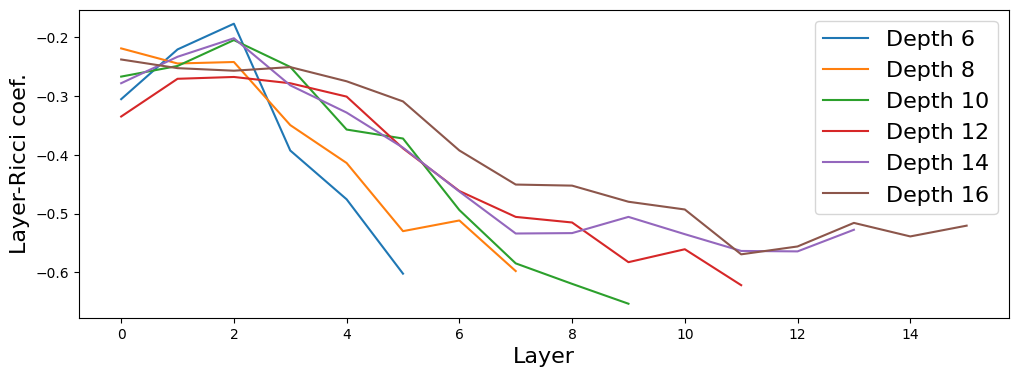

In [25]:
# Plot results
plt.figure(figsize=(12,4))
for i in range(len(layer_ricci_coefficients_res_net)):
    plt.plot(np.arange(len(layer_ricci_coefficients_res_net[i])-1),layer_ricci_coefficients_res_net[i][:-1], label=f"Depth {6+i*2}")
plt.legend(fontsize=16)
plt.xlabel("Layer", fontsize=16)
plt.ylabel("Layer-Ricci coef.", fontsize=16)

# Syn-III Dataset

In [10]:
# Load datasets
X_train_cylinder,y_train_cylinder = DatasetFactory.make_cylinders()
X_test_cylinder,y_test_cylinder = DatasetFactory.make_cylinders()

layer_ricci_coefficients_res_net = []
for depth in depths:
    layer_ricci_coefs_depth = []
    for _ in tqdm(range(num_iterations), desc=f"Depth={depth}"):
            # Train model
            model = ResNet(input_dimension=3, hidden_units=25, depth=depth, vision_model=False)
            train_model(
                threshold_accuracy=99,
                model=model,
                X_train=X_train_cylinder,
                y_train=y_train_cylinder,
                X_test=X_test_cylinder,
                y_test=y_test_cylinder
            )
            # Calculate layer Ricci coefficient
            layer_ricci = Ricci_Coefficients(
                model, X_test_cylinder, 50
            ).layer_ricci_coefficient(curv='Augmented-Forman-Ricci')
            layer_ricci_coefs_depth.append(layer_ricci)
    # Take means
    stacked = np.stack(layer_ricci_coefs_depth, axis=0)
    averaged_results = stacked.mean(axis=0)
    layer_ricci_coefficients_res_net.append(averaged_results)

Depth=6:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=8:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=10:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=12:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=14:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=16:   0%|          | 0/10 [00:00<?, ?it/s]

Text(0, 0.5, 'Layer-Ricci coef.')

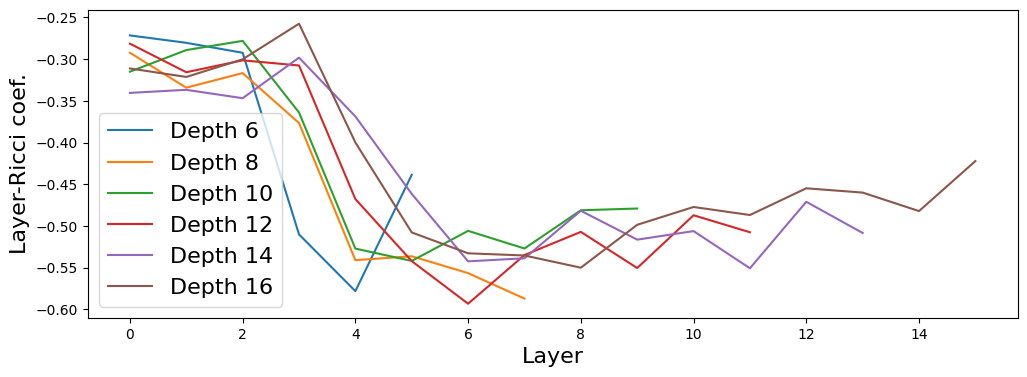

In [11]:
# Plot results
plt.figure(figsize=(12,4))
for i in range(len(layer_ricci_coefficients_res_net)):
    plt.plot(np.arange(len(layer_ricci_coefficients_res_net[i])-1),layer_ricci_coefficients_res_net[i][:-1], label=f"Depth {6+i*2}")
plt.legend(fontsize=16)
plt.xlabel("Layer", fontsize=16)
plt.ylabel("Layer-Ricci coef.", fontsize=16)

# Syn-IV Dataset

In [15]:
# Load datasets
X_train_tori, y_train_tori = DatasetFactory.make_tori()
X_test_tori, y_test_tori = DatasetFactory.make_tori()

layer_ricci_coefficients_res_net = []
for depth in depths:
    layer_ricci_coefs_depth = []
    for _ in tqdm(range(num_iterations), desc=f"Depth={depth}"):
            # Train model
            model = ResNet(input_dimension=3, hidden_units=25, depth=depth, vision_model=False)
            train_model(
                threshold_accuracy=99,
                model=model,
                X_train=X_train_tori,
                y_train=y_train_tori,
                X_test=X_test_tori,
                y_test=y_test_tori
            )
            # Calculate layer Ricci coefficient
            layer_ricci = Ricci_Coefficients(
                model, X_test_tori, 50
            ).layer_ricci_coefficient(curv='Augmented-Forman-Ricci')
            layer_ricci_coefs_depth.append(layer_ricci)
    # Take means
    stacked = np.stack(layer_ricci_coefs_depth, axis=0)
    averaged_results = stacked.mean(axis=0)
    layer_ricci_coefficients_res_net.append(averaged_results)

Depth=6:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=8:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=10:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=12:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=14:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=16:   0%|          | 0/10 [00:00<?, ?it/s]

Text(0, 0.5, 'Layer-Ricci coef.')

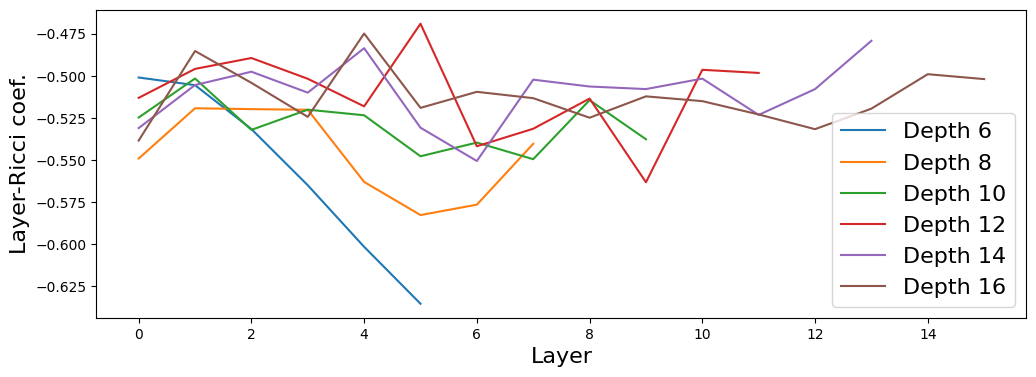

In [16]:
# Plot results
plt.figure(figsize=(12,4))
for i in range(len(layer_ricci_coefficients_res_net)):
    plt.plot(np.arange(len(layer_ricci_coefficients_res_net[i])-1),layer_ricci_coefficients_res_net[i][:-1], label=f"Depth {6+i*2}")
plt.legend(fontsize=16)
plt.xlabel("Layer", fontsize=16)
plt.ylabel("Layer-Ricci coef.", fontsize=16)

# MNIST 1 vs. 7 

In [26]:
# Load dataset
X_train_MNIST_17,y_train_MNIST_17, X_test_MNIST_17, y_test_MNIST_17 = DatasetFactory.load_MNIST(digits=(1,7))

layer_ricci_coefficients_res_net = []
for depth in depths:
    layer_ricci_coefs_depth = []
    for _ in tqdm(range(num_iterations), desc=f"Depth={depth}"):
            # Train model
            model = ResNet(input_dimension=784, hidden_units=25, depth=depth, vision_model=True)
            train_model(
                threshold_accuracy=99,
                model=model,
                X_train=X_train_MNIST_17,
                y_train=y_train_MNIST_17,
                X_test=X_test_MNIST_17,
                y_test=y_test_MNIST_17
            )
            # Calculate layer Ricci coefficient
            layer_ricci = Ricci_Coefficients(
                model, X_test_MNIST_17, 50
            ).layer_ricci_coefficient(curv='Augmented-Forman-Ricci')
            layer_ricci_coefs_depth.append(layer_ricci)
    # Take means
    stacked = np.stack(layer_ricci_coefs_depth, axis=0)
    averaged_results = stacked.mean(axis=0)
    layer_ricci_coefficients_res_net.append(averaged_results)

Depth=6:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=8:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=10:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=12:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=14:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=16:   0%|          | 0/10 [00:00<?, ?it/s]

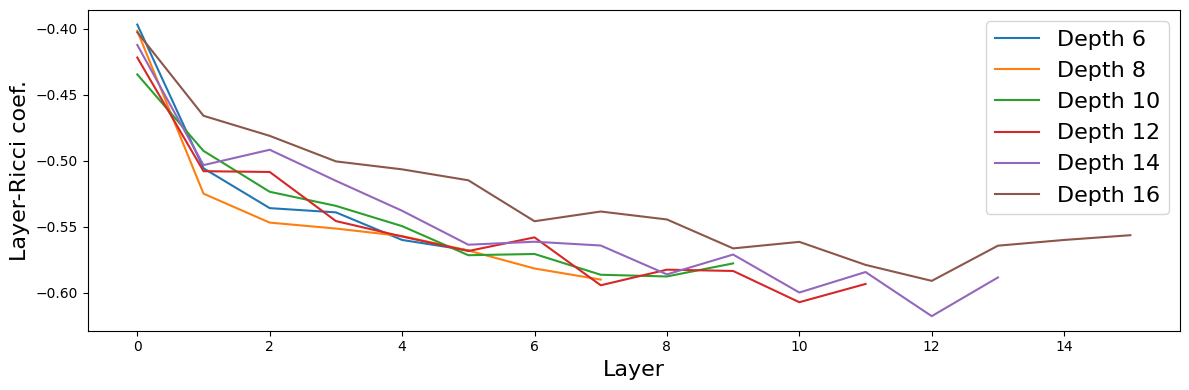

In [5]:
# Plot results
plt.figure(figsize=(12,4))
for i in range(len(layer_ricci_coefficients_res_net)):
    plt.plot(np.arange(len(layer_ricci_coefficients_res_net[i][:-1])),layer_ricci_coefficients_res_net[i][:-1], label=f"Depth {6+i*2}")
plt.legend(fontsize=16)
plt.xlabel("Layer", fontsize=16)
plt.ylabel("Layer-Ricci coef.", fontsize=16)

plt.tight_layout()
plt.savefig("../plots/Layer_Ricci_Coefficients_resnet.png", dpi=300, bbox_inches="tight") 
plt.show()

# MNIST 6v9

In [17]:
# Load dataset
X_train_MNIST_69,y_train_MNIST_69, X_test_MNIST_69, y_test_MNIST_69 = DatasetFactory.load_MNIST(digits=(6,9))

layer_ricci_coefficients_res_net = []
for depth in depths:
    layer_ricci_coefs_depth = []
    for _ in tqdm(range(num_iterations), desc=f"Depth={depth}"):
            # Train model
            model = ResNet(input_dimension=784, hidden_units=25, depth=depth, vision_model=True)
            train_model(
                threshold_accuracy=99,
                model=model,
                X_train=X_train_MNIST_69,
                y_train=y_train_MNIST_69,
                X_test=X_test_MNIST_69,
                y_test=y_test_MNIST_69
            )
            # Calculate layer Ricci coefficient
            layer_ricci = Ricci_Coefficients(
                model, X_test_MNIST_69, 50
            ).layer_ricci_coefficient(curv='Augmented-Forman-Ricci')
            layer_ricci_coefs_depth.append(layer_ricci)
    # Take means
    stacked = np.stack(layer_ricci_coefs_depth, axis=0)
    averaged_results = stacked.mean(axis=0)
    layer_ricci_coefficients_res_net.append(averaged_results)

Depth=6:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=8:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=10:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=12:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=14:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=16:   0%|          | 0/10 [00:00<?, ?it/s]

Text(0, 0.5, 'Layer-Ricci coef.')

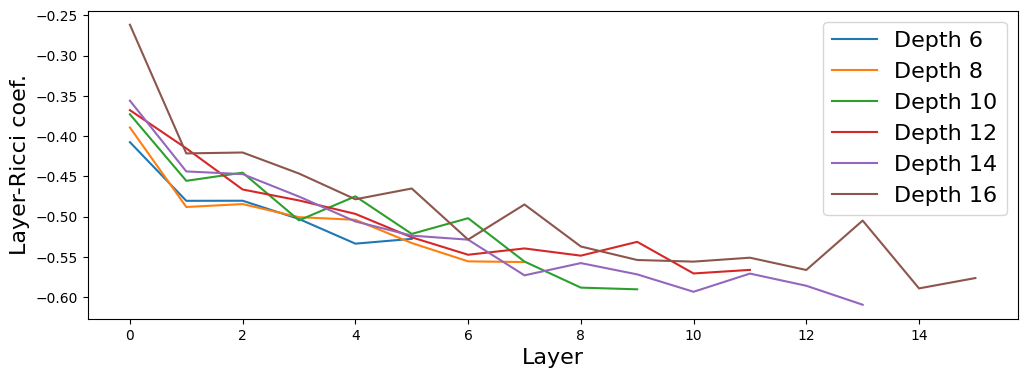

In [18]:
# Plot results
plt.figure(figsize=(12,4))
for i in range(len(layer_ricci_coefficients_res_net)):
    plt.plot(np.arange(len(layer_ricci_coefficients_res_net[i])-1),layer_ricci_coefficients_res_net[i][:-1], label=f"Depth {6+i*2}")
plt.legend(fontsize=16)
plt.xlabel("Layer", fontsize=16)
plt.ylabel("Layer-Ricci coef.", fontsize=16)

# Fashion-MNIST shoes

In [19]:
# Load datasets
X_train_fMNIST_shoes,y_train_fMNIST_shoes, X_test_fMNIST_shoes, y_test_fMNIST_shoes = DatasetFactory.load_fMNIST((5,7), device=device)

layer_ricci_coefficients_res_net = []
for depth in depths:
    layer_ricci_coefs_depth = []
    for _ in tqdm(range(num_iterations), desc=f"Depth={depth}"):
            # Train model
            model = ResNet(input_dimension=784, hidden_units=25, depth=depth, vision_model=True).to(device=device)
            train_model(
                threshold_accuracy=99,
                model=model,
                X_train=X_train_fMNIST_shoes,
                y_train=y_train_fMNIST_shoes,
                X_test=X_test_fMNIST_shoes,
                y_test=y_test_fMNIST_shoes
            )
            # Calculate layer Ricci coefficient
            layer_ricci = Ricci_Coefficients(
                model, X_test_fMNIST_shoes, 50
            ).layer_ricci_coefficient(curv='Augmented-Forman-Ricci')
            layer_ricci_coefs_depth.append(layer_ricci)
    # Take means
    stacked = np.stack(layer_ricci_coefs_depth, axis=0)
    averaged_results = stacked.mean(axis=0)
    layer_ricci_coefficients_res_net.append(averaged_results)

Depth=6:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=8:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=10:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=12:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=14:   0%|          | 0/10 [00:00<?, ?it/s]

Depth=16:   0%|          | 0/10 [00:00<?, ?it/s]

Text(0, 0.5, 'Layer-Ricci coef.')

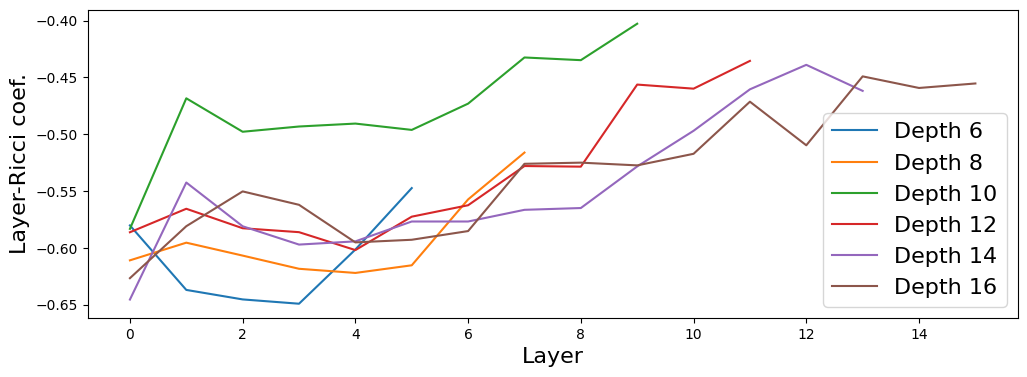

In [20]:
# Plot results
plt.figure(figsize=(12,4))
for i in range(len(layer_ricci_coefficients_res_net)):
    plt.plot(np.arange(len(layer_ricci_coefficients_res_net[i])-1),layer_ricci_coefficients_res_net[i][:-1], label=f"Depth {6+i*2}")
plt.legend(fontsize=16)
plt.xlabel("Layer", fontsize=16)
plt.ylabel("Layer-Ricci coef.", fontsize=16)

# Fashion-MNIST Apperal

In [ ]:
# Load dataset
X_train_fMNIST_apperal,y_train_fMNIST_apperal, X_test_fMNIST_apperal, y_test_fMNIST_apperal = DatasetFactory.load_fMNIST((3,6), device=device)

layer_ricci_coefficients_res_net = []
for depth in depths:
    layer_ricci_coefs_depth = []
    for _ in tqdm(range(num_iterations), desc=f"Depth={depth}"):
            # Train model
            model = ResNet(input_dimension=784, hidden_units=25, depth=depth, vision_model=True).to(device=device)
            train_model(
                threshold_accuracy=99,
                model=model,
                X_train=X_train_fMNIST_apperal,
                y_train=y_train_fMNIST_apperal,
                X_test=X_test_fMNIST_apperal,
                y_test=y_test_fMNIST_apperal
            )
            # Calculate layer Ricci coefficient
            layer_ricci = Ricci_Coefficients(
                model, X_test_fMNIST_apperal, 50
            ).layer_ricci_coefficient(curv='Augmented-Forman-Ricci')
            layer_ricci_coefs_depth.append(layer_ricci)
    # Take means
    stacked = np.stack(layer_ricci_coefs_depth, axis=0)
    averaged_results = stacked.mean(axis=0)
    layer_ricci_coefficients_res_net.append(averaged_results)

Text(0, 0.5, 'Layer-Ricci coef.')

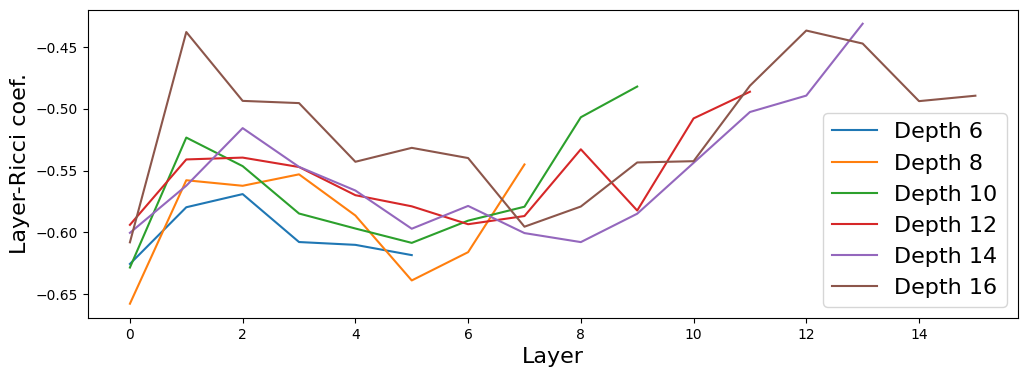

In [22]:
# Plot results
plt.figure(figsize=(12,4))
for i in range(len(layer_ricci_coefficients_res_net)):
    plt.plot(np.arange(len(layer_ricci_coefficients_res_net[i])-1),layer_ricci_coefficients_res_net[i][:-1], label=f"Depth {6+i*2}")
plt.legend(fontsize=16)
plt.xlabel("Layer", fontsize=16)
plt.ylabel("Layer-Ricci coef.", fontsize=16)